In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

data = {
    'Composition': ['NaCl', 'SiO2', 'Al2O3', 'MgO', 'CaO',
                    'Fe2O3', 'TiO2', 'ZnO', 'CuO', 'NiO'],
    'Stability': ['Stable', 'Stable', 'Stable', 'Stable', 'Stable',
                  'Stable', 'Stable', 'Stable', 'Unstable', 'Unstable']
}

df = pd.DataFrame(data)

df

,Composition,Stability
0,NaCl,Stable
1,SiO2,Stable
2,Al2O3,Stable
3,MgO,Stable
4,CaO,Stable
5,Fe2O3,Stable
6,TiO2,Stable
7,ZnO,Stable
8,CuO,Unstable
9,NiO,Unstable


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Composition  10 non-null     str  
 1   Stability    10 non-null     str  
dtypes: str(2)
memory usage: 393.0 bytes


In [6]:
df.isnull().sum()

Composition    0
Stability      0
dtype: int64

In [7]:
df['Stability_Label'] = df['Stability'].map({
    'Stable': 1,
    'Unstable': 0
})

df

,Composition,Stability,Stability_Label
0,NaCl,Stable,1
1,SiO2,Stable,1
2,Al2O3,Stable,1
3,MgO,Stable,1
4,CaO,Stable,1
5,Fe2O3,Stable,1
6,TiO2,Stable,1
7,ZnO,Stable,1
8,CuO,Unstable,0
9,NiO,Unstable,0


In [8]:
df['Formula_Length'] = df['Composition'].apply(len)

df['Num_Elements'] = df['Composition'].apply(
    lambda x: sum(1 for char in x if char.isupper())
)

df

,Composition,Stability,Stability_Label,Formula_Length,Num_Elements
0,NaCl,Stable,1,4,2
1,SiO2,Stable,1,4,2
2,Al2O3,Stable,1,5,2
3,MgO,Stable,1,3,2
4,CaO,Stable,1,3,2
5,Fe2O3,Stable,1,5,2
6,TiO2,Stable,1,4,2
7,ZnO,Stable,1,3,2
8,CuO,Unstable,0,3,2
9,NiO,Unstable,0,3,2


In [9]:
X = df[['Formula_Length', 'Num_Elements']]
y = df['Stability_Label']

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Formula_Length  Num_Elements
0               4             2
1               4             2
2               5             2
3               3             2
4               3             2
5               5             2
6               4             2
7               3             2
8               3             2
9               3             2

Target:
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    0
9    0
Name: Stability_Label, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 8
Testing data: 2


In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual values:", y_test.values)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Predictions: [1 1]
Actual values: [0 1]
Model Accuracy: 0.5


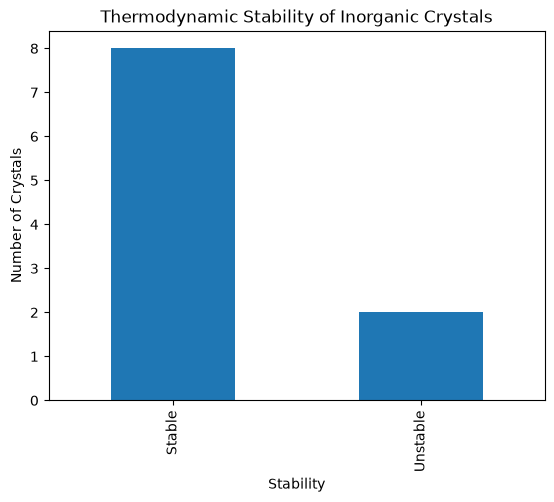

In [13]:
import matplotlib.pyplot as plt

df['Stability'].value_counts().plot(kind='bar')

plt.title("Thermodynamic Stability of Inorganic Crystals")
plt.xlabel("Stability")
plt.ylabel("Number of Crystals")

plt.show()

In [14]:
new_crystal = [[4, 2]]

prediction = model.predict(new_crystal)

if prediction[0] == 1:
    print("The inorganic crystal is Thermodynamically Stable")
else:
    print("The inorganic crystal is Thermodynamically Unstable")

The inorganic crystal is Thermodynamically Stable


C:\Users\Vallamsetti Devika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


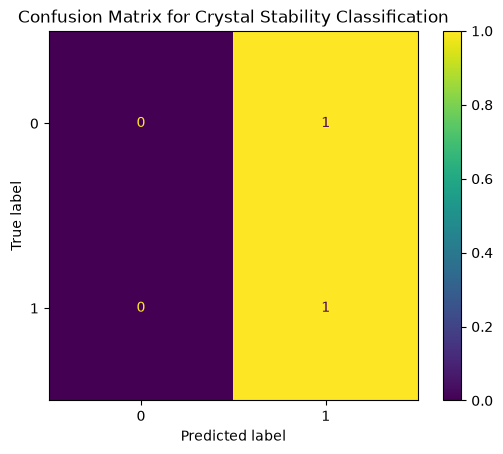

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Crystal Stability Classification")
plt.show()

In [16]:
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 50.00%


# Conclusion

This project successfully classified inorganic crystals as Thermodynamically Stable or Unstable based on chemical composition features.

A Random Forest Classifier was used to train the machine learning model. The model was evaluated using test data, and its performance was measured using accuracy and a confusion matrix.

The project demonstrates how Machine Learning can be used for predicting the thermodynamic stability of inorganic crystals.